# U-net Plots 

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd
import seaborn as sns

# path to lightning log folder
log_dir = "../../out/lightning_logs/version_1"

# load event files
event_acc = EventAccumulator(log_dir)
event_acc.Reload()

# available metrics
print("Available tags:", event_acc.Tags()["scalars"])

# extract values
def extract_metric(metric_name):
    if metric_name not in event_acc.Tags()["scalars"]:
        print(f"{metric_name} not found!")
        return None, None
    
    events = event_acc.Scalars(metric_name)
    epochs = np.arange(len(events))  
    values = [e.value for e in events]
    return epochs, np.array(values)

# extract metrics
train_loss_steps, train_loss = extract_metric("train_avg_loss")
epochs_val_loss, val_loss = extract_metric("val_avg_loss")

#train_iou_steps, train_iou = extract_metric("train_mean_iou", True)
val_iou_steps, val_iou = extract_metric("val_mean_iou")

Available tags: ['hp_metric', 'val_avg_loss', 'val_mean_iou', 'val_iou_0', 'val_iou_1', 'val_iou_2', 'val_iou_3', 'val_iou_4', 'val_iou_5', 'val_iou_6', 'epoch', 'train_avg_loss', 'train_iou_0', 'train_iou_1', 'train_iou_2', 'train_iou_3', 'train_iou_4', 'train_iou_5', 'train_iou_6', 'test_avg_loss', 'test_iou_0', 'test_iou_1', 'test_iou_2', 'test_iou_3', 'test_iou_4', 'test_iou_5', 'test_iou_6']


In [4]:
# extract values
def extract_metric(metric_name):
    if metric_name not in event_acc.Tags()["scalars"]:
        print(f"{metric_name} not found!")
        return None, None
    
    events = event_acc.Scalars(metric_name)
    epochs = np.arange(len(events))  
    values = [e.value for e in events]
    return epochs, np.array(values)

def plot_loss(log_dir):

    # load event files
    event_acc = EventAccumulator(log_dir)
    event_acc.Reload()

    # extract metrics
    train_loss_steps, train_loss = extract_metric("train_avg_loss")
    epochs_val_loss, val_loss = extract_metric("val_avg_loss")

    train_events = event_acc.Scalars("train_avg_loss")
    train_steps = np.array([e.step for e in train_events])
    train_values = np.array([e.value for e in train_events])

    # estimate steps per epoch
    num_epochs = len(val_loss)  # from validation 
    steps_per_epoch = len(train_values) // num_epochs

    train_loss_epoch = train_values.reshape(num_epochs, steps_per_epoch).mean(axis=1)
    epochs_train = np.arange(num_epochs)

    plt.figure()
    plt.plot(epochs_train, train_loss_epoch)
    plt.plot(epochs_val_loss, val_loss)
    plt.ylim(0, 0.04)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.title("Train vs Validation Loss", fontsize=16)
    plt.legend(["Train Loss", "Validation Loss"])
    plt.show()

    return event_acc


def plot_iou(event_acc):

    num_classes = 7

    train_class_ious = []

    for c in range(num_classes):
        events = event_acc.Scalars(f"train_iou_{c}")
        values = [e.value for e in events if e.value != 1.0]
        train_class_ious.append(values)

    train_class_ious = np.array(train_class_ious)

    train_mean_iou = np.nanmean(train_class_ious, axis=0)
    epochs = np.arange(len(train_mean_iou))

    val_events = event_acc.Scalars("val_mean_iou")
    val_mean_iou = np.array([e.value for e in val_events])

    plt.figure()
    plt.plot(epochs, train_mean_iou)
    plt.plot(epochs, val_mean_iou)

    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Mean IoU", fontsize=14)
    plt.title("Train vs Validation Mean IoU", fontsize=16)
    plt.legend(["Train Mean IoU", "Validation Mean IoU"])
    plt.show()

In [5]:
# plot testset IoUs

def plot_testset_iou_dice(file_path):
    df = pd.read_csv(file_path, header=0)

    df_long = df.melt(id_vars="id", 
                    value_vars=["iou_class_0", "iou_class_1", "iou_class_2", "iou_class_3", "iou_class_4", "iou_class_5", "iou_class_6",
                                "mean_iou"],
                    var_name="Class", value_name="IoU")
    
    # Boxen plot
    sns.boxenplot(x="Class", y="IoU", data=df_long, showfliers=False, linewidth=1.5, 
                k_depth='trustworthy')

    plt.title("IoU distribution for test images")
    plt.show()


    all_ious = df[[f'iou_class_{i}' for i in range(7)]].to_numpy()
    all_dices = df[[f'dice_class_{i}' for i in range(7)]].to_numpy()

    # remove 1.0 values per class
    iou_classes = [all_ious[:, i][all_ious[:, i] != 1.0] for i in range(7)]
    dice_classes = [all_dices[:, i][all_dices[:, i] != 1.0] for i in range(7)]

    mean_iou = np.concatenate(iou_classes)
    mean_dice = np.concatenate(dice_classes)

    # data for plotting
    iou_data = [mean_iou] + iou_classes
    dice_data = [mean_dice] + dice_classes

    iou_labels = ['Mean IoU'] + [f'Class {i}' for i in range(7)]
    dice_labels = ['Mean Dice'] + [f'Class {i}' for i in range(7)]

    mean_color = '#4C72B0'
    class_color = '#55A868'

    # IoU boxplot
    fig, ax = plt.subplots(figsize=(10,6))
    box = ax.boxplot(iou_data, patch_artist=True)

    for i, patch in enumerate(box['boxes']):
        patch.set_facecolor(mean_color if i == 0 else class_color)

    ax.set_ylabel("IoU")
    ax.set_title("IoU Distribution")
    ax.set_xticklabels(iou_labels)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Dice boxplot
    fig, ax = plt.subplots(figsize=(10,6))
    box = ax.boxplot(dice_data, patch_artist=True)

    for i, patch in enumerate(box['boxes']):
        patch.set_facecolor(mean_color if i == 0 else class_color)

    ax.set_ylabel("Dice")
    ax.set_title("Dice Distribution")
    ax.set_xticklabels(dice_labels)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

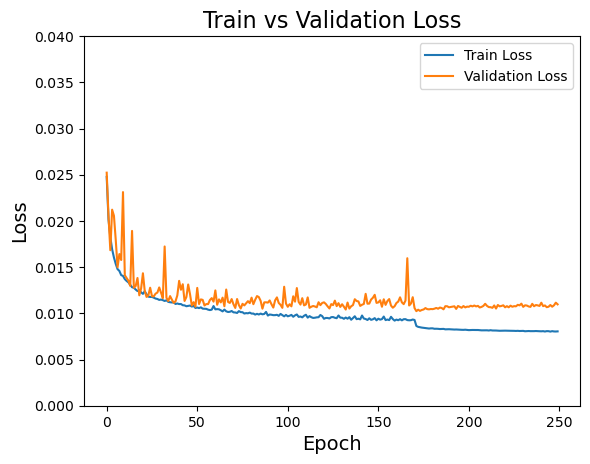

In [10]:
event_acc = plot_loss("../../out/lightning_logs/version_1")

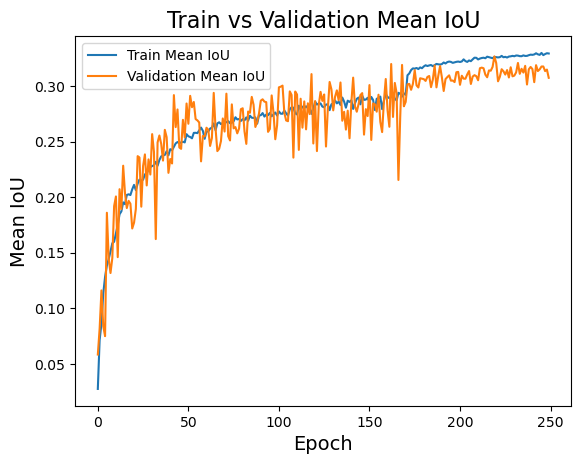

In [13]:
plot_iou(event_acc)

#### data augmentation --log-interval 5 --epochs 250 --weight-decay 0.00001 --dropout-val 0.001 --lr 0.0002 --training-batch-size 8 --test-batch-size 8

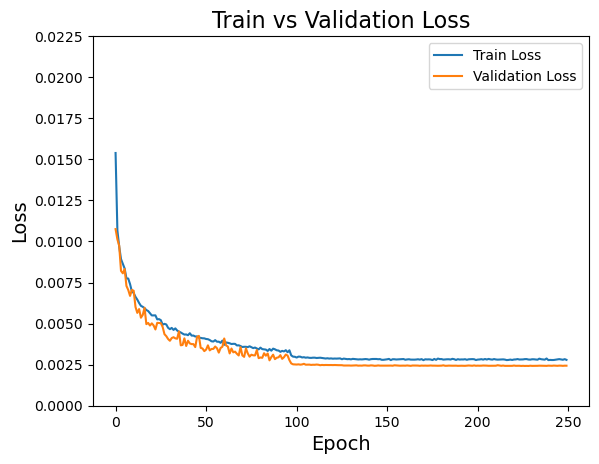

In [16]:
event_acc = plot_loss("../../out/lightning_logs/version_36")

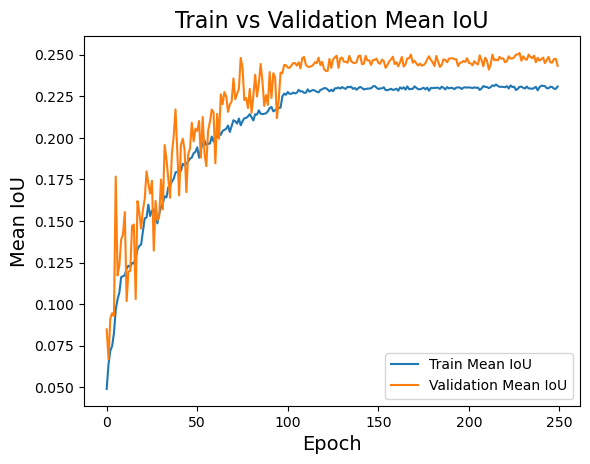

In [18]:
plot_iou(event_acc)

#### no aug lr-0.003_wd-1e-05_dropout-0.01_epoch-250_batchS-64 (tuned para except batch size), filters [32,64,128,256]

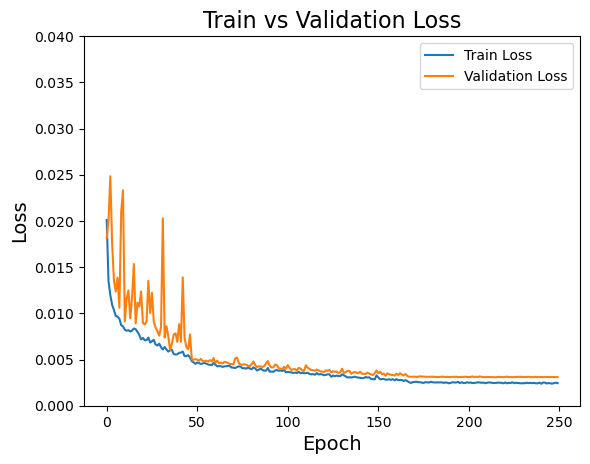

In [12]:
event_acc = plot_loss("../../mlruns/unet_fromC32_noAug/version_4")

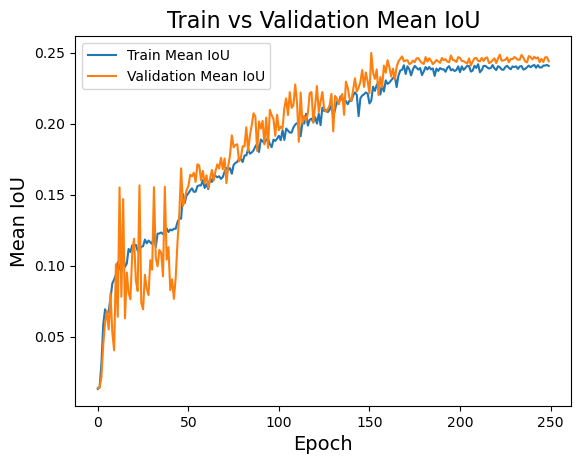

In [14]:
plot_iou(event_acc)

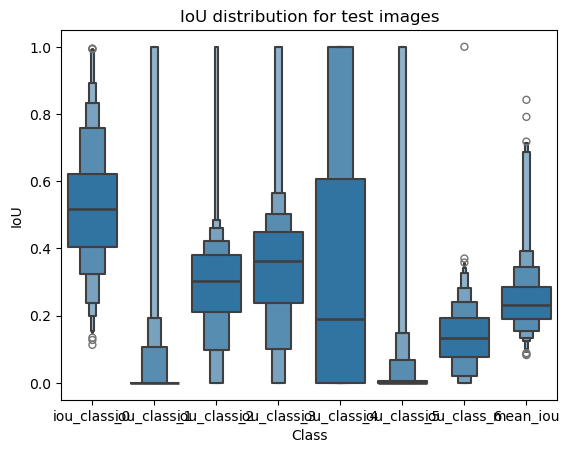

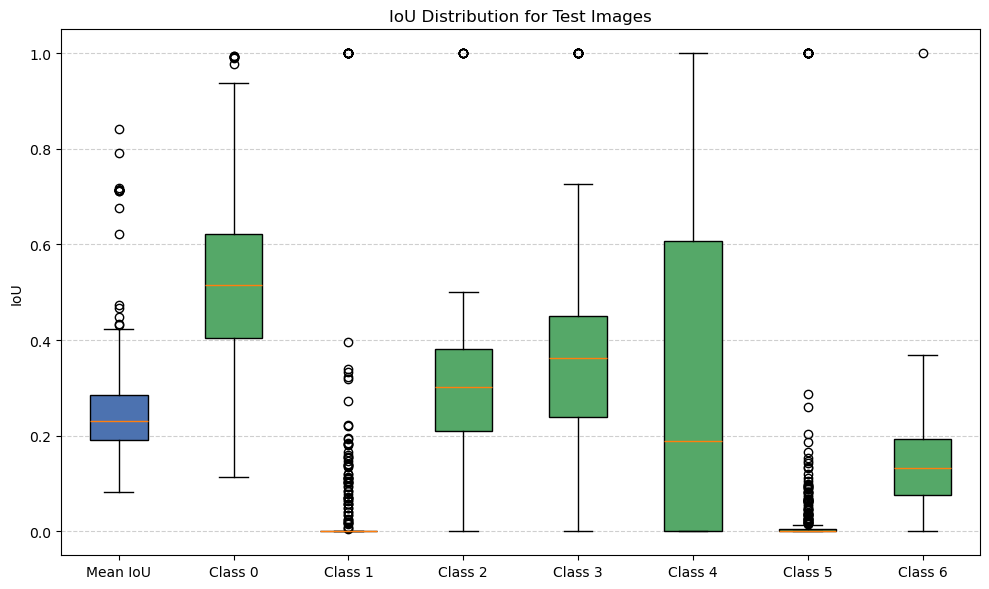

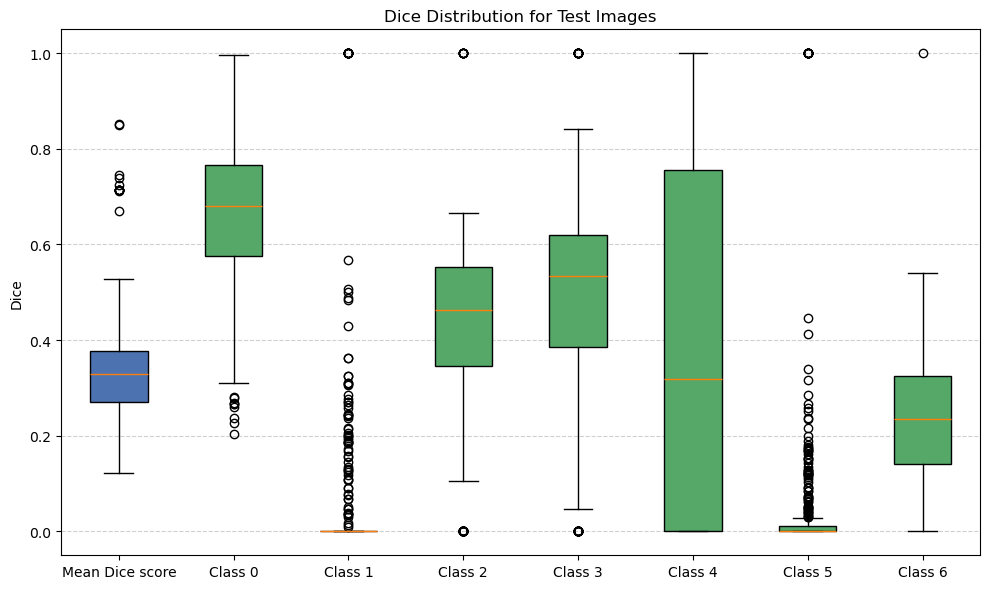

In [16]:
plot_testset_iou_dice("../../mlruns/unet_fromC32_noAug/test_metrics_per_image_Unet_lr-0.003_wd-1e-05_dropout-0.01_epoch-250_batchS-32.csv")

#### Aug, background class weight 0.5, channel dim starts with 32, --epochs 250 --lr 0.003 --weight-decay 0.00001 --training-batch-size 64 --test-batch-size 32 --dropout-val 0.015

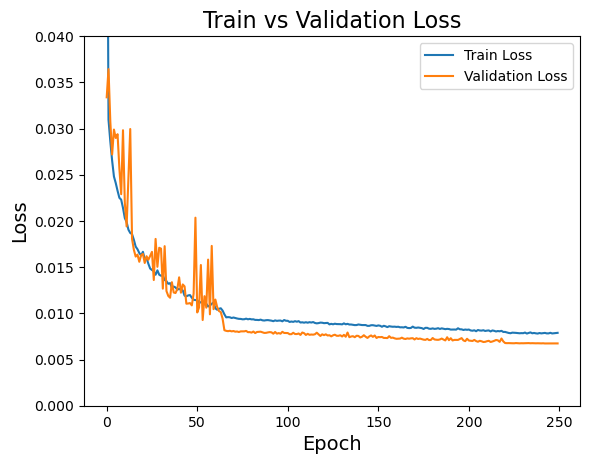

In [9]:
event_acc = plot_loss("../../mlruns/unet_fromC32_Aug_backgound0_5/version_29")

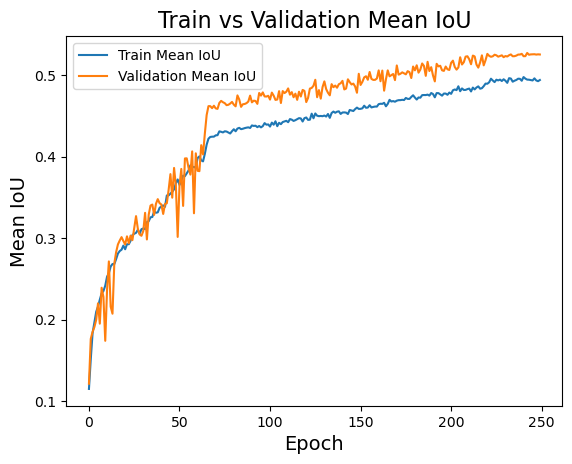

In [20]:
plot_iou(event_acc)

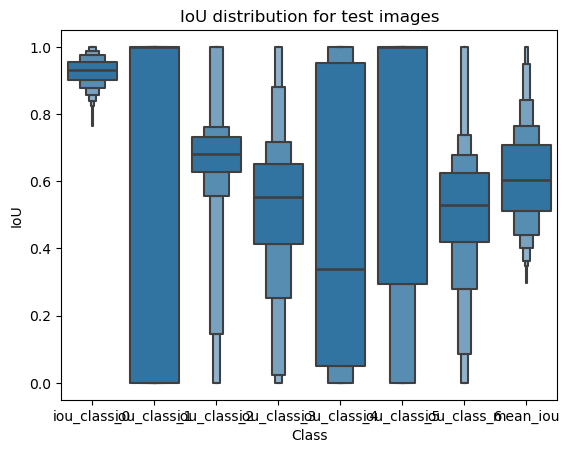

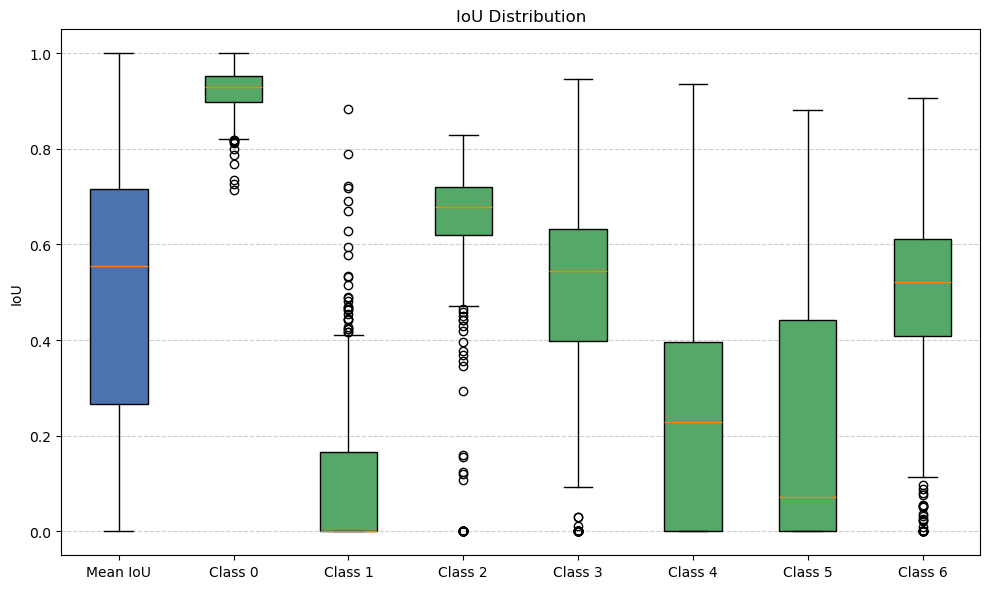

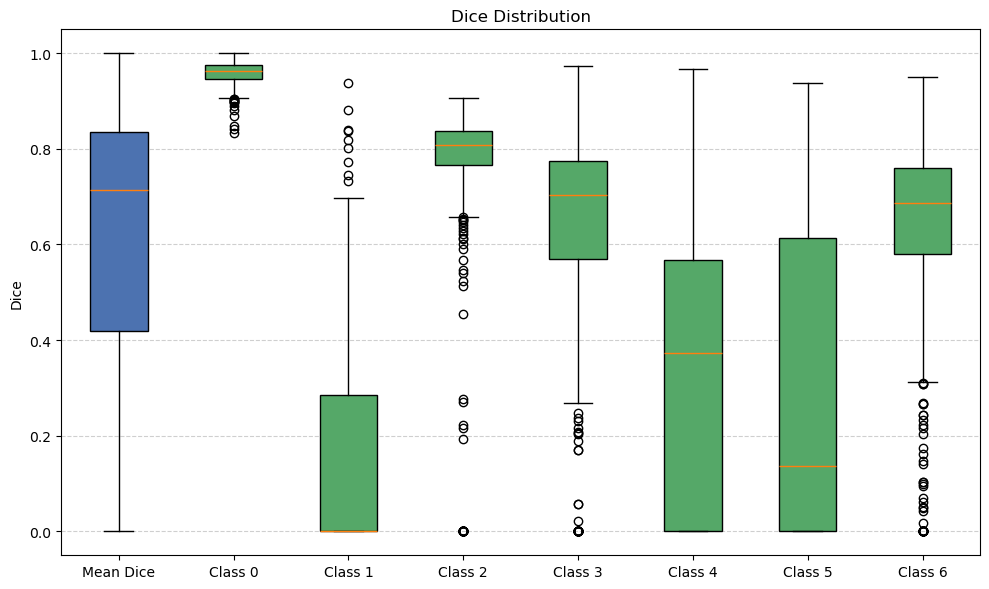

In [6]:
plot_testset_iou_dice("../../mlruns/unet_fromC32_Aug_backgound0_5/test_metrics_per_image_Unet_lr-0.003_wd-1e-05_dropout-0.015_epoch-250_batchS-32.csv")